In [10]:
# pip install jieba
# !pip install snownlp
# !pip install pymysql

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/e5/30/20467e39523d0cfc2b6227902d3687a16364307260c75e6a1cb4422b0c62/PyMySQL-1.1.0-py3-none-any.whl (44 kB)


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
# 设置 Matplotlib 支持中文的字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是一种常用的中文字体
matplotlib.rcParams['font.family']='sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False  # 正确显示负号

In [11]:
import jieba
from collections import Counter
import matplotlib.pyplot as plt

# ...（前面的代码不变）

from snownlp import SnowNLP
import pandas as pd
import pymysql


In [19]:


# main():
sql = 'select  id,nickname, score, content, productColor, creationTime from data order by creationTime'
con = pymysql.connect(host='127.0.0.1', user='root', passwd='123456', port=3306, db='comment1', charset='utf8mb4')
df = pd.read_sql(sql, con)
df.drop_duplicates(keep='first', inplace=True)
df = df.dropna()
content = df['content'].tolist()
contentlist = []
for x in content:
    contentlist.append(SnowNLP(x).sentiments)
df['nlp'] = contentlist
df = df[['nickname', 'score', 'content', 'nlp']]
df.to_csv('nlp.csv')
print(df)
#     return df


# main()





D:\360Downloads\Anaconda\anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


     nickname  score                                            content  \
0       萌***脸      5  一直在这里买这个，活动的时候价格很美丽，发货速度贼快，质量不错，应该是正品，十分感谢小紫的细心讲解   
1       j***˜      5            效果效果非常的好，非常的满意。 多次在这家购买。还会回购的，大家可以放心购买。   
2       狗***罐      5  给老公买的，老公说喝了这么多的蛋白粉还是康比特的乳清蛋白粉味道好，而且十分好溶解，喝了一桶啦...   
3       头***3      5  哈哈哈哈，我简直就是康比特的老粉丝了啊，他们家的蛋白粉啊、健肌粉、肌酸我差不多都买过啦。产品...   
4       l***6      5                        性价比很高的一款乳清蛋白粉，味道好，物流很快，小紫推荐   
...       ...    ...                                                ...   
1751    乡***2      5  汤臣倍健蛋白粉质量非常得好，味道也是很不错的效果也很好，给家里老人买的还满意，活动期间下单的...   
1752    乡***2      5  汤臣倍健蛋白粉质量非常得好，味道也是非常不错的，很纯给家里老人买的让人非常的喜欢效果，也是很...   
1753    奶***爱      5  买给亲戚的，因为他以前吃一直说蛋白粉吃的很好，所以双十一帮她囤一点等他吃的好，我再自己买一点...   
1754    j***j      5                                        一直在在这里超级超级👍   
1755    我***哥      5  营养搭配：产品真的超级棒，下次还会买的，愿越做越好，非常好的购物体验客服服务态度很好，快递也...   

           nlp  
0     0.999994  
1     0.977922  
2     0.917190  
3     0.973766  
4     0.999262

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\lenove\AppData\Local\Temp\jieba.cache
Loading model cost 1.725 seconds.
Prefix dict has been built successfully.
D:\360Downloads\Anaconda\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\360Downloads\Anaconda\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\360Downloads\Anaconda\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\360Downloads\Anaconda\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 35770 (\N{CJK UNIFIED IDEOGRAPH-8BBA}) missing from current 

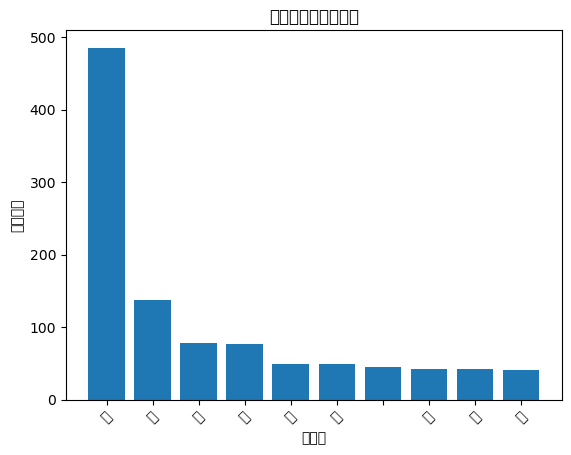

[('，', 485), ('。', 137), ('！', 78), ('买', 77), ('好', 49), ('喝', 49), (' ', 45), ('都', 42), ('不', 42), ('还', 41)]


In [20]:

def extract_negative_features(df, sentiment_threshold=0.3):
    # 筛选情感分数低于阈值的负面评论
    negative_reviews = df[df['nlp'] <= sentiment_threshold]
    
    # 提取关键词
    words = []
    for review in negative_reviews['content']:
        words.extend(jieba.lcut(review))
    
    # 计算词频
    word_freq = Counter(words)
    
    # 移除停用词
    stop_words = set()
    with open("chinese_stopwords.txt", 'r', encoding='utf-8') as f:
        for line in f:
            stop_wordswords.add(line.strip())
#     return stopwords
#     stop_words = set(['的', '了', '是'])  # 这里可以扩展常见的停用词
    for stop_word in stop_words:
        if stop_word in word_freq:
            del word_freq[stop_word]
    
    
    # 获取最常见的负面关键词
    common_words = word_freq.most_common(10)
    
    # 可视化负面关键词
    words, freqs = zip(*common_words)
    plt.bar(words, freqs)
    plt.xlabel('关键词')
    plt.ylabel('出现次数')
    plt.title('负面评论关键词频率')
    plt.xticks(rotation=45)
    plt.show()
    
    return negative_reviews, common_words

# ...（主函数中调用 extract_negative_features）
# def main():
#     # ...（其余代码不变）

#     # 返回DataFrame
#     return df

if __name__ == '__main__':
    # 调用main函数，并接收返回的df
#     df = main()

    # 使用返回的df调用extract_negative_features函数
    negative_reviews, common_words = extract_negative_features(df)
    print(common_words)


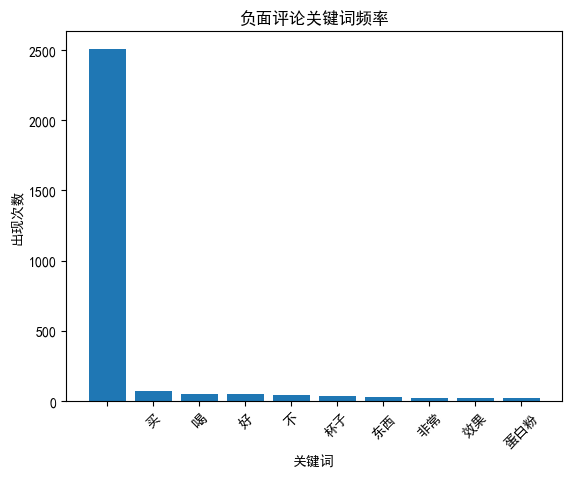

[(' ', 2507), ('买', 75), ('喝', 49), ('好', 47), ('不', 45), ('杯子', 34), ('东西', 29), ('非常', 25), ('效果', 24), ('蛋白粉', 23)]


In [26]:
import re
import jieba
import pandas as pd
import pymysql
from snownlp import SnowNLP
from collections import Counter
# import matplotlib.pyplot as plt

# 函数：读取停用词文件
def load_stopwords(filepath):
    stopwords = set()
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            stopwords.add(line.strip())
    return stopwords

# 函数：去除程度词
def remove_degree_words(text, degree_words):
    for word in degree_words:
        text = re.sub(r'\b{}\b'.format(word), '', text)
    return text

# 函数：清洗和分词
def preprocess_text(input_text, stopwords, degree_words):
    # 去除程度词
    text_without_degree_words = remove_degree_words(input_text, degree_words)

    # 去除特殊字符
    text_cleaned = re.sub(r'[^\w\s]', '', text_without_degree_words)

    # 分词
    words = jieba.cut(text_cleaned, cut_all=False)

    # 过滤停用词和程度词
    words_filtered = [word for word in words if word not in stopwords and word not in degree_words]

    return ' '.join(words_filtered)

# 函数：提取负面评价特征并可视化
def extract_negative_features(df, sentiment_threshold=0.3, stopwords=None, degree_words=None):
    # 筛选情感分数低于阈值的负面评论
    negative_reviews = df[df['nlp'] <= sentiment_threshold]
    
    # 预处理和分词
    words = []
    for review in negative_reviews['content']:
        processed_text = preprocess_text(review, stopwords, degree_words)
        words.extend(jieba.lcut(processed_text))
    
    # 计算词频
    word_freq = Counter(words)
    
    # 获取最常见的负面关键词
    common_words = word_freq.most_common(10)
    
    # 可视化负面关键词
    words, freqs = zip(*common_words)
    plt.bar(words, freqs)
    plt.xlabel('关键词')
    plt.ylabel('出现次数')
    plt.title('负面评论关键词频率')
    plt.xticks(rotation=45)
    plt.show()

    return negative_reviews, common_words

# 主程序
def main():
    # 数据库连接配置
    con = pymysql.connect(host='127.0.0.1', user='root', passwd='123456', port=3306, db='comment1', charset='utf8mb4')

    # 从数据库中提取数据
#     sql = 'SELECT content FROM comment1'
#     df = pd.read_sql(sql, con)
    sql = 'select  id,nickname, score, content, productColor, creationTime from data order by creationTime'
    con = pymysql.connect(host='127.0.0.1', user='root', passwd='123456', port=3306, db='comment1', charset='utf8mb4')

    # 情感分析
    df['nlp'] = df['content'].apply(lambda x: SnowNLP(x).sentiments)

    # 停用词和程度词的处理
    stopwords = load_stopwords('chinese_stopwords.txt')
    degree_words = ["很", "还", "更加", "蛮", "确实", "更", "都", "挺"]

    # 提取和可视化负面评价特征
    negative_reviews, common_words = extract_negative_features(df, sentiment_threshold=0.3, stopwords=stopwords, degree_words=degree_words)

    print(common_words)

if __name__ == '__main__':
    main()
